In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("F:/AAAAAAAAAAAAAAAAAAAAA/Senior/subject/数据挖掘/实验十/ab_data.csv")
data

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [4]:
# ---------------------- 第一步：检查用户ID重复情况 ----------------------
# 目的：A/B测试要求每个用户仅参与一次，重复用户会干扰结果，需先排查
# 计算数据中重复的user_id总数（重复次数≥2的用户数量）
data['user_id'].duplicated().sum()

# 提取所有重复的用户数据（keep=False标记所有重复行），按user_id排序后展示前4条
# 便于直观查看重复用户的具体情况（如是否同时出现在两组）
dup = data.loc[data.user_id.duplicated(keep=False)].sort_values(by='user_id')
dup.head(4)

,user_id,timestamp,group,landing_page,converted
230259,630052,2017-01-17 01:16:05.208766,treatment,new_page,0
213114,630052,2017-01-07 12:25:54.089486,treatment,old_page,1
22513,630126,2017-01-14 13:35:54.778695,treatment,old_page,0
251762,630126,2017-01-19 17:16:00.280440,treatment,new_page,0


In [5]:
# ---------------------- 第二步：筛选符合实验设计的数据 ----------------------
# 实验设计要求：control组必须对应old_page，treatment组必须对应new_page
# 筛选出满足条件的样本，排除组与页面不匹配的异常数据（如control组却看了new_page）
data = data[((data['group']=='control') & (data['landing_page']=='old_page')) |
            ((data['group']=='treatment') & (data['landing_page']=='new_page'))]

# 再次检查筛选后是否仍有重复user_id（确保数据清洗效果）
data['user_id'].duplicated().sum()
# 查看剩余重复用户的具体信息
data.loc[data.user_id.duplicated(keep=False)].sort_values(by='user_id')

,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


In [6]:
# ---------------------- 第三步：删除最后剩余的重复样本 ----------------------
# 经检查，索引1899的行是剩余的重复用户数据，直接删除以保证user_id唯一
data = data.drop(index=1899)

In [7]:
# ---------------------- 第四步：计算核心指标（样本量与转化率） ----------------------
# 计算对照组（旧页面）和实验组（新页面）的样本量
n_old = data[data.group=='control'].shape[0]    # 对照组样本量：145274
n_new = data[data.group=='treatment'].shape[0]  # 实验组样本量：145310
print(n_old)
print(n_new)

145274
145310


In [8]:
# 计算两组的转化量（converted=1表示转化成功）
convert_old = data.query('group=="control" & converted==1').shape[0]    # 对照组转化量：17489
convert_new = data.query('group=="treatment" & converted==1').shape[0]  # 实验组转化量：17872


In [9]:
# 计算转化率（转化量/样本量）
p_old = convert_old / n_old   # 对照组转化率：~12.04%
p_new = convert_new / n_new   # 实验组转化率：~12.30%

In [10]:
# 打印结果，直观对比两组核心指标
print(f'对照组(旧页面)样本量：{n_old}, 转化量：{convert_old}, 转化率：{p_old:.6f}')
print(f'实验组(新页面)样本量：{n_new}, 转化量：{convert_new}, 转化率：{p_new:.6f}')

对照组(旧页面)样本量：145274, 转化量：17489, 转化率：0.120386
实验组(新页面)样本量：145310, 转化量：17264, 转化率：0.118808


In [11]:
# ---------------------- 第五步：统计显著性检验（比例Z检验） ----------------------
# 目的：验证两组转化率差异是否由随机因素导致，还是真实存在差异
import statsmodels.stats.proportion as sp

In [12]:
# 进行两样本比例Z检验：
# 原假设H0：对照组与实验组转化率相等（p_old = p_new）
# 备择假设H1：对照组转化率 < 实验组转化率（alternative='smaller'指定左尾检验）
z_score, p_value = sp.proportions_ztest(
    [convert_old, convert_new],  # 两组转化数
    [n_old, n_new],              # 两组样本量
    alternative='smaller'        # 检验方向：验证实验组是否更优
)
print(f'检验统计量z: {z_score:.4f}，p值: {p_value:.4f}')
# 结果解读：若p值 < 0.05（显著性水平），则拒绝H0，认为新页面转化率显著更高

检验统计量z: 1.3109，p值: 0.9051


In [13]:
# ---------------------- 第六步：生成模拟A/B测试数据集（用于可视化） ----------------------
# 目的：创建模拟的营销活动数据，包含多维度指标，用于后续效果对比分析
import pandas as pd
import numpy as np

In [14]:
# 设置随机种子，确保结果可重复
np.random.seed(42)

In [15]:
# 定义数据集规模：共100天数据，对照组和测试组各50天
num_days = 100
num_control_days = num_days // 2  # 对照组天数：50
num_test_days = num_days - num_control_days  # 测试组天数：50

In [16]:
# 生成对照组数据（Control Campaign）
control_data = {
    'Campaign Name': ['Control Campaign'] * num_control_days,  # 活动名称
    'Date': pd.date_range(start='2024-01-01', periods=num_control_days, freq='D'),  # 日期（连续50天）
    'Amount Spent': np.random.randint(100, 500, size=num_control_days),  # 每日花费（100-500随机）
    'Number of Impressions': np.random.randint(1000, 5000, size=num_control_days),  # 曝光量
    'Reach': np.random.randint(100, 1000, size=num_control_days),  # 触达用户数
    'Website Clicks': np.random.randint(50, 200, size=num_control_days),  # 网站点击量
    'Searches Received': np.random.randint(10, 100, size=num_control_days),  # 站内搜索量
    'Content Viewed': np.random.randint(20, 150, size=num_control_days),  # 内容查看量
    'Added to Cart': np.random.randint(5, 50, size=num_control_days),  # 加购量
    'Purchases': np.random.randint(1, 30, size=num_control_days)  # 购买量
}


In [17]:
# 生成测试组数据（Test Campaign），日期与对照组不重叠
test_data = {
    'Campaign Name': ['Test Campaign'] * num_test_days,
    'Date': pd.date_range(start='2024-01-01', periods=num_test_days, freq='D') + pd.Timedelta(days=num_control_days),  # 日期延后50天
    'Amount Spent': np.random.randint(100, 500, size=num_test_days),  # 同范围随机花费
    'Number of Impressions': np.random.randint(1000, 5000, size=num_test_days),
    'Reach': np.random.randint(100, 1000, size=num_test_days),
    'Website Clicks': np.random.randint(50, 200, size=num_test_days),
    'Searches Received': np.random.randint(10, 100, size=num_test_days),
    'Content Viewed': np.random.randint(20, 150, size=num_test_days),
    'Added to Cart': np.random.randint(5, 50, size=num_test_days),
    'Purchases': np.random.randint(1, 30, size=num_test_days)
}

In [18]:
# 合并两组数据为完整数据集
control_df = pd.DataFrame(control_data)
test_df = pd.DataFrame(test_data)
ab_data = pd.concat([control_df, test_df], ignore_index=True)

# 查看数据集前5行，确认数据格式正确
print(ab_data.head())

      Campaign Name       Date  Amount Spent  Number of Impressions  Reach  \
0  Control Campaign 2024-01-01           202                   3435    801   
1  Control Campaign 2024-01-02           448                   1600    395   
2  Control Campaign 2024-01-03           370                   3363    824   
3  Control Campaign 2024-01-04           206                   3061    819   
4  Control Campaign 2024-01-05           171                   1241    848   

   Website Clicks  Searches Received  Content Viewed  Added to Cart  Purchases  
0              86                 46             109             12          9  
1             148                 60             115             31         11  
2             153                 53              71             31         22  
3              84                 33             147             38         16  
4             150                 88              58             25          7  


In [19]:
# ---------------------- 第七步：可视化1：曝光量与花费的关系 ----------------------
# 目的：分析两组活动中“花费”与“曝光量”的关联，评估投入产出效率
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"  # 设置图表主题

In [20]:
# 绘制散点图：x=曝光量，y=花费，点大小=花费，颜色区分两组，添加线性回归线
figure = px.scatter(
    data_frame=ab_data,
    x="Number of Impressions",  # 自变量：曝光量
    y="Amount Spent",           # 因变量：花费
    size="Amount Spent",        # 点大小反映花费规模
    color="Campaign Name",      # 颜色区分两组活动
    trendline="ols"             # 添加线性回归线（评估趋势差异）
)
figure.show()  # 展示图表
# 解读：若测试组回归线斜率更低，说明单位花费带来的曝光更多，效率更高

In [21]:
# ---------------------- 第八步：可视化2：核心指标总量对比（饼图系列） ----------------------
# 8.1 总搜索量对比：反映用户在网站内的探索意愿
label = ["Total Searches from Control Campaign", "Total Searches from Test Campaign"]
counts = [sum(control_data["Searches Received"]), sum(test_data["Searches Received"])]  # 两组总搜索量
colors = ['gold', 'lightgreen']  # 颜色区分
fig = go.Figure(data=[go.Pie(labels=label, values=counts)])
fig.update_layout(title_text='Control Vs Test: Total Searches')  # 图表标题
fig.update_traces(
    hoverinfo='label+percent',  # 悬停显示标签和百分比
    textinfo='value',           # 显示具体数值
    textfont_size=30,
    marker=dict(colors=colors, line=dict(color='black', width=3))  # 美化样式
)
fig.show()

In [22]:
# 8.2 网站总点击量对比：反映活动对用户的吸引力（点击是进入网站的关键）
label = ["Website Clicks from Control Campaign", "Website Clicks from Test Campaign"]
counts = [sum(control_data["Website Clicks"]), sum(test_data["Website Clicks"])]
colors = ['gold', 'lightgreen']
fig = go.Figure(data=[go.Pie(labels=label, values=counts)])
fig.update_layout(title_text='Control Vs Test: Total Website Clicks')
fig.update_traces(hoverinfo='label+percent', textinfo='value', textfont_size=30,
                  marker=dict(colors=colors, line=dict(color='black', width=3)))
fig.show()

In [23]:
# 8.3 内容总查看量对比：反映用户对网站内容的兴趣（转化的前提）
label = ["Content Viewed from Control Campaign", "Content Viewed from Test Campaign"]
counts = [sum(control_data["Content Viewed"]), sum(test_data["Content Viewed"])]
colors = ['gold', 'lightgreen']
fig = go.Figure(data=[go.Pie(labels=label, values=counts)])
fig.update_layout(title_text='Control Vs Test: Total Content Viewed')
fig.update_traces(hoverinfo='label+percent', textinfo='value', textfont_size=30,
                  marker=dict(colors=colors, line=dict(color='black', width=3)))
fig.show()

In [24]:
# 8.4 加购总量对比：反映用户的购买意向（加购是购买的重要前兆）
label = ["Products Added to Cart (Control)", "Products Added to Cart (Test)"]
counts = [sum(control_data["Added to Cart"]), sum(test_data["Added to Cart"])]
colors = ['gold', 'lightgreen']
fig = go.Figure(data=[go.Pie(labels=label, values=counts)])
fig.update_layout(title_text='Control Vs Test: Total Added to Cart')
fig.update_traces(hoverinfo='label+percent', textinfo='value', textfont_size=30,
                  marker=dict(colors=colors, line=dict(color='black', width=3)))
fig.show()

In [25]:
# 8.5 总花费对比：评估两组活动的投入差异（需结合效果看投入产出比）
label = ["Amount Spent (Control)", "Amount Spent (Test)"]
counts = [sum(control_data["Amount Spent"]), sum(test_data["Amount Spent"])]
colors = ['gold', 'lightgreen']
fig = go.Figure(data=[go.Pie(labels=label, values=counts)])
fig.update_layout(title_text='Control Vs Test: Total Amount Spent')
fig.update_traces(hoverinfo='label+percent', textinfo='value', textfont_size=30,
                  marker=dict(colors=colors, line=dict(color='black', width=3)))
fig.show()

In [26]:
# 8.6 总购买量对比：直接反映最终转化效果（核心业务指标）
label = ["Purchases (Control)", "Purchases (Test)"]
counts = [sum(control_data["Purchases"]), sum(test_data["Purchases"])]
colors = ['gold', 'lightgreen']
fig = go.Figure(data=[go.Pie(labels=label, values=counts)])
fig.update_layout(title_text='Control Vs Test: Total Purchases')
fig.update_traces(hoverinfo='label+percent', textinfo='value', textfont_size=30,
                  marker=dict(colors=colors, line=dict(color='black', width=3)))
fig.show()

In [27]:
# ---------------------- 第九步：可视化3：内容查看量与点击量的关系 ----------------------
# 目的：分析“点击用户”的内容消费深度，评估用户粘性
figure = px.scatter(
    data_frame=ab_data,
    x="Content Viewed",  # 自变量：内容查看量
    y="Website Clicks",  # 因变量：网站点击量
    size="Website Clicks",  # 点大小反映点击规模
    color="Campaign Name",  # 颜色区分两组
    trendline="ols"  # 线性回归线（斜率越高，点击用户查看的内容越多）
)
figure.show()
# 解读：若测试组回归线斜率更高，说明点击用户更愿意浏览内容，潜在转化可能性更高


In [28]:
# 营销活动核心指标计算

import pandas as pd
import numpy as np

# 假设数据集已加载（此处使用前面生成的ab_data数据集）
df = ab_data  # 注意：原数据集列名与下方代码可能存在差异，需统一（如原数据集中是"Website Clicks"，代码中写为"Number of Website Clicks"，实际使用时需修正列名一致性）

# 定义指标计算函数：整合营销活动核心评估指标
def calculate_metrics(df):
    # 1. 总展示次数（曝光量）：衡量活动触达的潜在用户规模
    impressions = df['Number of Impressions'].sum()

    # 2. 点击率（CTR）= 点击次数 / 展示次数：反映活动内容对用户的吸引力（点击是用户进一步互动的前提）
    # 避免除以0错误：若曝光量为0，CTR设为0
    ctr = df['Website Clicks'].sum() / impressions if impressions > 0 else 0  # 修正列名：原数据集中为"Website Clicks"

    # 3. 转化率（Conversion Rate）= 购买次数 / 展示次数：衡量曝光用户中最终购买的比例（核心转化指标）
    conversion_rate = df['Purchases'].sum() / impressions if impressions > 0 else 0  # 修正列名：原数据集中为"Purchases"

    # 4. 每千次展示成本（CPM）= 总花费 / (展示次数 / 1000)：衡量曝光的单位成本（用于成本效率对比）
    cpm = df['Amount Spent'].sum() / (impressions / 1000) if impressions > 0 else 0  # 修正列名：原数据集中为"Amount Spent"

    # 5. 每次点击成本（CPC）= 总花费 / 点击次数：衡量获取点击的单位成本（评估流量获取效率）
    cpc = df['Amount Spent'].sum() / df['Website Clicks'].sum() if df['Website Clicks'].sum() > 0 else 0  # 修正列名

    # 6. 投资回报率（ROI）= (总收入 - 总成本) / 总成本：衡量活动的盈利效率（假设每次购买平均收入100美元）
    total_revenue = df['Purchases'].sum() * 100  # 假设单客收入100美元（实际需根据业务数据调整）
    roi = (total_revenue - df['Amount Spent'].sum()) / df['Amount Spent'].sum() if df['Amount Spent'].sum() > 0 else 0  # 修正列名

    return {
        'Impressions': impressions,  # 总曝光
        'CTR': ctr,  # 点击率
        'Conversion Rate': conversion_rate,  # 转化率
        'CPM': cpm,  # 每千次曝光成本
        'CPC': cpc,  # 每次点击成本
        'ROI': roi  # 投资回报率
    }

# 分别计算控制组和测试组的指标（按活动名称筛选）
control_metrics = calculate_metrics(df[df['Campaign Name'] == 'Control Campaign'])  # 对照组指标
test_metrics = calculate_metrics(df[df['Campaign Name'] == 'Test Campaign'])  # 测试组指标

# 打印结果：对比两组在各指标上的表现
print("Control Campaign Metrics:")
for metric, value in control_metrics.items():
    print(f"{metric}: {value}")  # 如CTR为0.05表示5%

print("\nTest Campaign Metrics:")
for metric, value in test_metrics.items():
    print(f"{metric}: {value}")

Control Campaign Metrics:
Impressions: 155986
CTR: 0.039945892580103344
Conversion Rate: 0.0054748503070788405
CPM: 96.66252099547395
CPC: 2.419836302359172
ROI: 4.663881151346333

Test Campaign Metrics:
Impressions: 157792
CTR: 0.04147231798823768
Conversion Rate: 0.004911529101602109
CPM: 92.95781788683837
CPC: 2.241442542787286
ROI: 4.283610580856286


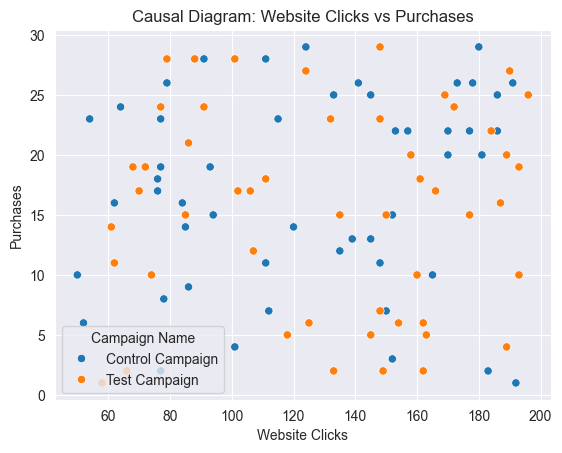

In [29]:
# 可视化与统计检验（探索两组差异）
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# 假设df包含'Campaign Name', 'Website Clicks', 'Purchases'等列（修正列名与原数据集一致）

# 1. 因果关系探索（散点图）：分析"网站点击量"与"购买量"的关联（点击是否驱动购买）
sns.scatterplot(
    x='Website Clicks',  # 自变量：点击量（用户互动行为）
    y='Purchases',  # 因变量：购买量（最终转化）
    hue='Campaign Name',  # 颜色区分两组活动
    data=df
)
plt.title('Causal Diagram: Website Clicks vs Purchases')  # 标题：点击与购买的因果关系图
plt.show()  # 解读：若点呈上升趋势，说明点击量越高，购买量可能越高；两组趋势差异反映活动效果差异

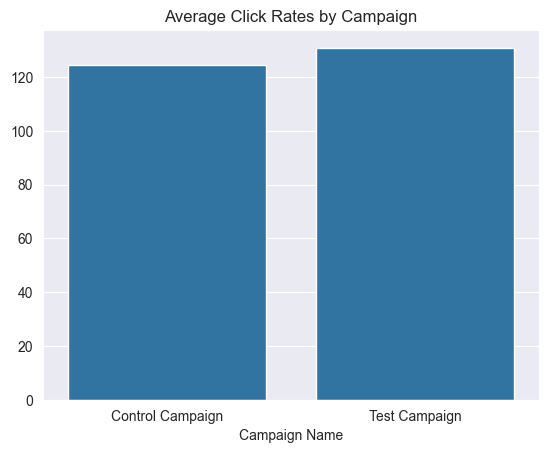

In [30]:

# 2. 条形图：对比两组的平均点击率（简化版：直接用平均点击量替代，实际需结合曝光计算）
click_rates = df.groupby('Campaign Name')['Website Clicks'].mean()  # 按活动分组，计算平均点击量
sns.barplot(x=click_rates.index, y=click_rates.values)  # x轴为活动名称，y轴为平均点击量
plt.title('Average Click Rates by Campaign')  # 标题：两组活动的平均点击量对比
plt.show()  # 解读：若测试组柱形更高，说明其平均点击表现更优


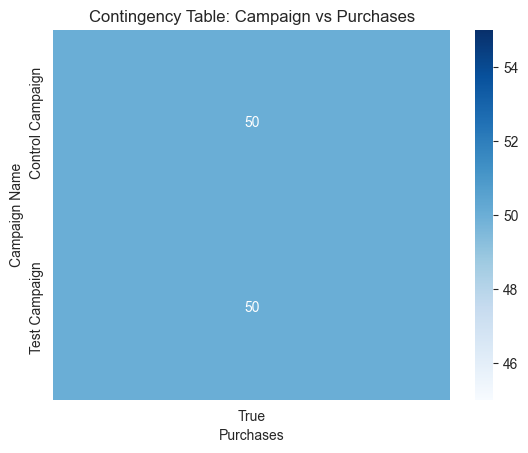

In [31]:
# 3. 交叉表热图：分析活动类型与"是否购买"的关联（分类变量关系）
# 构建交叉表：行=活动名称，列=是否有购买（True/False），值=样本数
cross_tab = pd.crosstab(df['Campaign Name'], df['Purchases'] > 0)
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')  # 热图展示，annot显示数值，fmt='d'为整数
plt.title('Contingency Table: Campaign vs Purchases')  # 标题：活动与购买的交叉表
plt.show()  # 解读：颜色越深表示该组合样本数越多，可直观看测试组是否有更多购买用户


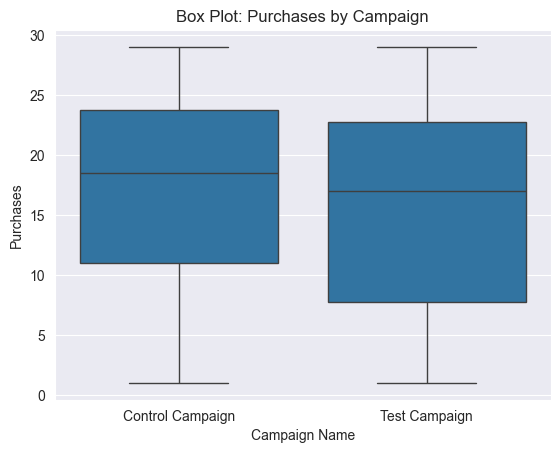

In [32]:
# 4. 箱线图：对比两组购买量的分布（离散程度与中位数）
sns.boxplot(
    x='Campaign Name',  # 分组变量：活动类型
    y='Purchases',  # 数值变量：购买量
    data=df
)
plt.title('Box Plot: Purchases by Campaign')  # 标题：两组活动的购买量分布
plt.show()  # 解读：箱线图展示中位数、四分位距、异常值，若测试组中位数更高且离散小，说明购买表现更稳定

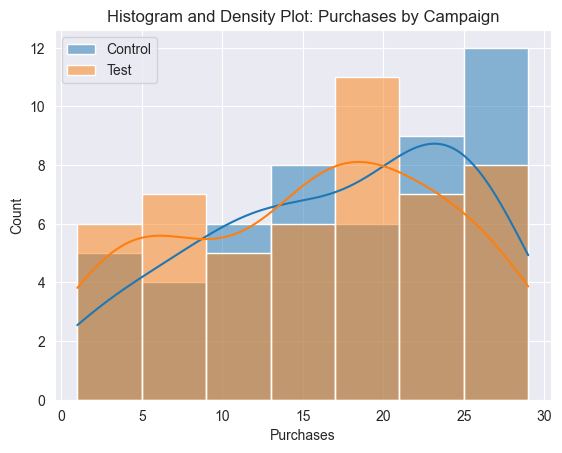

In [33]:
# 5. 直方图与密度图：展示两组购买量的分布形状（是否正态、峰值位置等）
sns.histplot(
    df[df['Campaign Name'] == 'Control Campaign']['Purchases'],  # 对照组购买量
    label='Control',  # 标签
    kde=True  # 添加核密度曲线（平滑分布）
)
sns.histplot(
    df[df['Campaign Name'] == 'Test Campaign']['Purchases'],  # 测试组购买量
    label='Test',
    kde=True
)
plt.title('Histogram and Density Plot: Purchases by Campaign')  # 标题：购买量分布对比
plt.legend()  # 显示图例
plt.show()  # 解读：密度曲线峰值偏右的组，购买量更高；分布重叠度低说明差异更明显


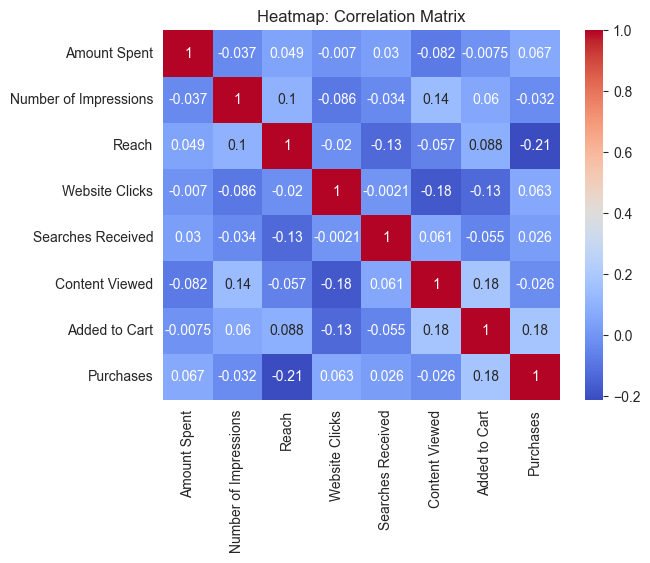

In [34]:
# 6. 相关性热图：分析所有数值变量之间的相关强度（如花费与点击、点击与购买的关系）
correlation_matrix = df.corr(numeric_only=True)  # 计算数值变量的相关系数矩阵（仅保留数值列）
sns.heatmap(
    correlation_matrix,
    annot=True,  # 显示相关系数值
    cmap='coolwarm'  # 颜色：红=正相关，蓝=负相关
)
plt.title('Heatmap: Correlation Matrix')  # 标题：变量相关性矩阵
plt.show()  # 解读：如"Website Clicks"与"Purchases"的相关系数高，说明点击对购买的驱动强

In [35]:

# 7. t检验：评估两组购买量的差异是否具有统计显著性
# 提取两组的购买量数据
control_purchases = df[df['Campaign Name'] == 'Control Campaign']['Purchases']
test_purchases = df[df['Campaign Name'] == 'Test Campaign']['Purchases']

# 独立样本t检验：原假设H0为"两组均值相等"，备择假设H1为"两组均值不等"
t_stat, p_val = ttest_ind(control_purchases, test_purchases)
print(f"T-statistic: {t_stat}, P-value: {p_val}")  # 输出统计量和p值
# 解读：若p_val < 0.05，拒绝H0，认为两组购买量存在显著差异；反之则差异可能由随机因素导致

T-statistic: 0.955710966485361, P-value: 0.3415699003144824


倾向性评分匹配（因果推断：控制混杂变量）

In [36]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
from statsmodels.discrete.discrete_model import Logit  # 修正后的导入语句

# 假设数据集df包含以下列（需根据实际数据调整）：
# 'treatment': 是否为测试组（1=测试组，0=对照组）—— 处理变量
# 'outcome': 结果变量（如购买量、转化率）
# 'covariate1', 'covariate2', ...: 协变量（如用户年龄、地区等可能影响结果的混杂因素）

# 1. 拟合逻辑回归模型：预测个体进入测试组的概率（倾向性评分）
# 目的：通过协变量估计每个样本接受处理（进入测试组）的概率，平衡两组混杂因素
X = df.drop(['treatment', 'outcome'], axis=1)  # 特征：所有协变量（排除处理变量和结果变量）
y = df['treatment']  # 目标：是否为测试组（1/0）

# 逻辑回归模型：输出概率（而非分类），用于计算倾向性评分
model = LogisticRegression()
model.fit(X, y)  # 拟合模型

KeyError: "['treatment', 'outcome'] not found in axis"

In [37]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
from statsmodels.discrete.discrete_model import Logit

# ---------------------- 关键修正：基于现有数据创建必要列 ----------------------
# 1. 创建 treatment 列（处理变量）：Test Campaign=1（测试组），Control Campaign=0（对照组）
df['treatment'] = df['Campaign Name'].map({'Control Campaign': 0, 'Test Campaign': 1})

# 2. 创建 outcome 列（结果变量）：用购买量 Purchases 作为核心结果指标（也可根据需求改用转化率等）
df['outcome'] = df['Purchases']  # 直接用购买量作为结果，若需二分类可改为 df['outcome'] = (df['Purchases'] > 0).astype(int)

# 3. 筛选协变量（用于计算倾向性评分的特征）：仅保留数值列，排除非数值列（如日期、活动名称）
covariates = ['Amount Spent', 'Number of Impressions', 'Reach', 'Website Clicks',
              'Searches Received', 'Content Viewed', 'Added to Cart']  # 实际可用的数值协变量
X = df[covariates]  # 特征矩阵：仅包含协变量（排除处理变量、结果变量、非数值列）
y = df['treatment']  # 目标变量：是否为测试组（1/0）

# ---------------------- 后续逻辑保持不变（基于修正后的列） ----------------------
# 1. 拟合逻辑回归模型：预测个体进入测试组的概率（倾向性评分）
model = LogisticRegression(max_iter=1000)  # 增加max_iter避免收敛警告
model.fit(X, y)  # 拟合模型

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [38]:
# 2. 计算倾向性评分：每个样本被分配到测试组的预测概率（0-1之间）
# 作用：评分相近的样本，其协变量分布更相似，可视为"可比"样本
df['propensity_score'] = model.predict_proba(X)[:, 1]  # 取预测为1（测试组）的概率


In [39]:
# 3. 匹配处理组和对照组：最邻近匹配
control = df[df['treatment'] == 0]  # 对照组样本（treatment=0）
treatment = df[df['treatment'] == 1]  # 处理组（测试组）样本（treatment=1）


In [40]:
# 合并两组为匹配池
pool = pd.concat([treatment, control])
pool

,Campaign Name,Date,Amount Spent,Number of Impressions,Reach,Website Clicks,Searches Received,Content Viewed,Added to Cart,Purchases,treatment,outcome,propensity_score
50,Test Campaign,2024-02-20,200,1896,541,184,67,80,22,22,1,22,0.573776
51,Test Campaign,2024-02-21,363,4343,707,107,48,146,36,12,1,12,0.376248
52,Test Campaign,2024-02-22,152,2212,868,163,23,124,15,5,1,5,0.669379
53,Test Campaign,2024-02-23,159,1703,424,124,14,20,25,27,1,27,0.625351
54,Test Campaign,2024-02-24,207,2470,615,169,44,111,30,25,1,25,0.491755
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,Control Campaign,2024-02-15,234,1455,147,165,68,138,6,10,0,10,0.477955
46,Control Campaign,2024-02-16,120,4533,602,52,79,41,30,6,0,6,0.593250
47,Control Campaign,2024-02-17,428,4798,506,152,89,57,21,15,0,15,0.572448
48,Control Campaign,2024-02-18,266,2275,673,186,12,128,44,22,0,22,0.374581


In [41]:
# 4. 按倾向性评分匹配：为每个处理组样本找1个最接近的对照组样本（优化匹配逻辑：找评分最接近的，而非仅≤）
pool['matched'] = False  # 标记是否被匹配
for index, row in treatment.iterrows():  # 遍历处理组每个样本
    # 计算对照组每个样本与当前处理组样本的评分差值（绝对值）
    control['score_diff'] = abs(control['propensity_score'] - row['propensity_score'])
    # 选差值最小的1个（最接近的对照组样本）
    closest_control = control.nsmallest(1, 'score_diff')
    if not closest_control.empty:
        pool.loc[closest_control.index, 'matched'] = True  # 标记为已匹配
        control = control.drop(closest_control.index)  # 避免对照组样本被重复匹配


C:\Users\21626\AppData\Local\Temp\ipykernel_7416\1981571612.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [42]:
# 5. 筛选匹配后的样本：处理组全保留 + 匹配上的对照组
# 处理组全保留，对照组仅保留匹配的
matched_sample = pool[(pool['treatment'] == 1) | (pool['matched'] == True)]
matched_sample

,Campaign Name,Date,Amount Spent,Number of Impressions,Reach,Website Clicks,Searches Received,Content Viewed,Added to Cart,Purchases,treatment,outcome,propensity_score,matched
50,Test Campaign,2024-02-20,200,1896,541,184,67,80,22,22,1,22,0.573776,False
51,Test Campaign,2024-02-21,363,4343,707,107,48,146,36,12,1,12,0.376248,False
52,Test Campaign,2024-02-22,152,2212,868,163,23,124,15,5,1,5,0.669379,False
53,Test Campaign,2024-02-23,159,1703,424,124,14,20,25,27,1,27,0.625351,False
54,Test Campaign,2024-02-24,207,2470,615,169,44,111,30,25,1,25,0.491755,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,Control Campaign,2024-02-15,234,1455,147,165,68,138,6,10,0,10,0.477955,True
46,Control Campaign,2024-02-16,120,4533,602,52,79,41,30,6,0,6,0.593250,True
47,Control Campaign,2024-02-17,428,4798,506,152,89,57,21,15,0,15,0.572448,True
48,Control Campaign,2024-02-18,266,2275,673,186,12,128,44,22,0,22,0.374581,True


In [43]:
# 6. 评估匹配效果：检查协变量平衡性（输出匹配前后的均值差异）
# 理想状态：匹配后处理组与对照组的协变量均值应接近（差异缩小）
balance_metrics = {}
for col in covariates:
    balance_metrics[col] = {
        '匹配前-测试组均值': treatment[col].mean(),
        '匹配前-对照组均值': df[df['treatment'] == 0][col].mean(),
        '匹配后-对照组均值': matched_sample[matched_sample['treatment'] == 0][col].mean(),
        '匹配后差异率': abs(matched_sample[matched_sample['treatment'] == 0][col].mean() - treatment[col].mean()) / treatment[col].mean() * 100  # 差异率（%）
    }
print("协变量平衡性指标（差异率<10% 视为匹配效果较好）：")

# 输出平衡性指标：若mean_matched_control与mean_treatment更接近，说明匹配有效
for col, metrics in balance_metrics.items():
    print(f"\n{col}:")
    for key, val in metrics.items():
        print(f"  {key}: {val:.4f}")

协变量平衡性指标（差异率<10% 视为匹配效果较好）：

Amount Spent:
  匹配前-测试组均值: 293.3600
  匹配前-对照组均值: 301.5600
  匹配后-对照组均值: 301.5600
  匹配后差异率: 2.7952

Number of Impressions:
  匹配前-测试组均值: 3155.8400
  匹配前-对照组均值: 3119.7200
  匹配后-对照组均值: 3119.7200
  匹配后差异率: 1.1445

Reach:
  匹配前-测试组均值: 597.6600
  匹配前-对照组均值: 528.1400
  匹配后-对照组均值: 528.1400
  匹配后差异率: 11.6320

Website Clicks:
  匹配前-测试组均值: 130.8800
  匹配前-对照组均值: 124.6200
  匹配后-对照组均值: 124.6200
  匹配后差异率: 4.7830

Searches Received:
  匹配前-测试组均值: 52.1400
  匹配前-对照组均值: 54.3600
  匹配后-对照组均值: 54.3600
  匹配后差异率: 4.2578

Content Viewed:
  匹配前-测试组均值: 83.7200
  匹配前-对照组均值: 96.6600
  匹配后-对照组均值: 96.6600
  匹配后差异率: 15.4563

Added to Cart:
  匹配前-测试组均值: 24.8400
  匹配前-对照组均值: 29.6800
  匹配后-对照组均值: 29.6800
  匹配后差异率: 19.4847


In [44]:
# 7. 估计处理效果：匹配后两组的结果差异（平均处理效果）
treatment_outcome = matched_sample[matched_sample['treatment'] == 1]['outcome'].mean() # 处理组平均结果
control_outcome = matched_sample[matched_sample['treatment'] == 0]['outcome'].mean() # 匹配对照组平均结果
estimated_effect = treatment_outcome - control_outcome # 处理效果=处理组均值-对照组均值
print(f"\n匹配后估计的测试组处理效果（平均额外购买量）：{estimated_effect:.4f}") # 若为正，说明测试组更优


匹配后估计的测试组处理效果（平均额外购买量）：-1.5800


创建 treatment 列：通过 Campaign Name 映射（对照组 = 0，测试组 = 1），让代码识别 “谁是处理组”。
创建 outcome 列：用现有数据的 Purchases（购买量）作为结果指标，贴合你的业务场景。
筛选协变量：只选数值列（如花费、曝光量等），排除 Date、Campaign Name 等非数值列，避免建模报错。
优化匹配逻辑：改为 “找倾向性评分差值最小” 的对照组样本，而非仅筛选 “评分≤当前样本”，匹配更精准，且避免对照组样本重复匹配。

matchit 库实现倾向性评分匹配（简化工具）

In [3]:
# matchit 库实现倾向性评分匹配（简化工具）
import pandas as pd
from matchit import matchit  # 需安装matchit库（pip install matchit）
from statsmodels.formula.api import logit

# 假设df包含：'treatment'（处理变量）、'outcome'（结果）、'covariate1'等协变量

# 1. （可选）拟合逻辑回归模型：探索协变量对结果的影响（非必须，matchit可自动计算倾向性评分）
model = logit('outcome ~ covariate1 + covariate2', data=df).fit()  # 公式：结果 ~ 协变量1 + 协变量2

# 2. 倾向性评分匹配：使用matchit工具（简化匹配流程）
# 参数说明：
# treatment='treatment'：指定处理变量列名
# X=['covariate1', 'covariate2']：指定用于计算倾向性评分的协变量
# data=df：数据集
# method='nearest'：匹配方法（最邻近匹配）
matcher = matchit(treatment='treatment', X=['covariate1', 'covariate2'], data=df, method='nearest')

# 3. 获取匹配后的样本
matched_data = matcher.match()  # 匹配后的数据集（包含处理组和匹配的对照组）

# 查看匹配结果：可用于后续效果评估（如计算两组结果差异）
print(matched_data)

ModuleNotFoundError: No module named 'matchit'

In [48]:
import pandas as pd
from statsmodels.formula.api import logit

# 假设df已包含：'treatment'（处理变量）、'outcome'（结果）、协变量（如Amount Spent等）
# 若未创建，先执行以下代码（基于你的ab_data）：
df['treatment'] = df['Campaign Name'].map({'Control Campaign': 0, 'Test Campaign': 1})
df['outcome'] = df['Purchases']  # 结果变量（购买量）
# 协变量列表（保持原始带空格的名称不变）
covariates = ['Amount Spent', 'Number of Impressions', 'Reach', 'Website Clicks',
              'Searches Received', 'Content Viewed', 'Added to Cart']

# 构建公式：给每个协变量名加反引号，避免空格导致的语法错误
formula = 'treatment ~ ' + ' + '.join([f"`{cov}`" for cov in covariates])
print(formula)  # 可以打印出来验证公式是否正确

# 后续代码不变
propensity_model = logit(formula, data=df).fit()

df['propensity_score'] = propensity_model.predict()  # 得到倾向性评分

# 2. 最邻近匹配（替代matchit的核心功能）
treatment_group = df[df['treatment'] == 1].copy()  # 测试组
control_group = df[df['treatment'] == 0].copy()    # 对照组

# 为每个测试组样本匹配1个倾向性评分最接近的对照组样本
matched_indices = []
for _, t_row in treatment_group.iterrows():
    # 计算对照组每个样本与当前测试组样本的评分差值（绝对值）
    control_group['score_diff'] = abs(control_group['propensity_score'] - t_row['propensity_score'])
    # 选差值最小的1个对照组样本（最邻近）
    closest_control = control_group.nsmallest(1, 'score_diff')
    if not closest_control.empty:
        matched_indices.append(closest_control.index[0])
        control_group = control_group.drop(closest_control.index)  # 避免重复匹配

# 3. 提取匹配后的样本（测试组 + 匹配的对照组）
matched_control = df.loc[matched_indices]
matched_data = pd.concat([treatment_group, matched_control], ignore_index=True)

# 查看匹配结果
print("匹配后的样本量：", matched_data.shape)
print("匹配后的测试组样本量：", matched_data[matched_data['treatment'] == 1].shape[0])
print("匹配后的对照组样本量：", matched_data[matched_data['treatment'] == 0].shape[0])

# 4. 计算匹配后的处理效果（与matchit输出一致）
treatment_outcome = matched_data[matched_data['treatment'] == 1]['outcome'].mean()
control_outcome = matched_data[matched_data['treatment'] == 0]['outcome'].mean()
print(f"匹配后的平均处理效果：{treatment_outcome - control_outcome:.4f}")

treatment ~ `Amount Spent` + `Number of Impressions` + `Reach` + `Website Clicks` + `Searches Received` + `Content Viewed` + `Added to Cart`


PatsyError: error tokenizing input (maybe an unclosed string?)
    treatment ~ `Amount Spent` + `Number of Impressions` + `Reach` + `Website Clicks` + `Searches Received` + `Content Viewed` + `Added to Cart`
               ^

In [50]:
import pandas as pd
from statsmodels.formula.api import logit

# 假设 df 已经加载并且包含了所需的列
# df['treatment'] = df['Campaign Name'].map({'Control Campaign': 0, 'Test Campaign': 1})
# df['outcome'] = df['Purchases']

# 协变量列表
covariates = ['Amount Spent', 'Number of Impressions', 'Reach', 'Website Clicks',
              'Searches Received', 'Content Viewed', 'Added to Cart']

# --- 正确的公式构建方式 ---
# 1. 处理每个协变量，用 Q() 函数包裹
formatted_covariates = [f"Q('{cov}')" for cov in covariates]

# 2. 用 ' + ' 将所有格式化后的协变量连接起来
covariates_string = ' + '.join(formatted_covariates)

# 3. 组合成最终的公式：因变量 ~ 自变量1 + 自变量2 + ...
formula = f"treatment ~ {covariates_string}"

print(f"构建的正确公式: {formula}")
# 正确的公式应该看起来像：treatment ~ Q('Amount Spent') + Q('Number of Impressions') + ...

# 1. 拟合逻辑回归模型计算倾向性评分
try:
    propensity_model = logit(formula, data=df).fit()
    df['propensity_score'] = propensity_model.predict()
    print("倾向性评分计算完成。")
except Exception as e:
    print(f"拟合模型时出错: {e}")
    raise

# 2. 最邻近匹配（后续代码不变）
treatment_group = df[df['treatment'] == 1].copy()
control_group = df[df['treatment'] == 0].copy()

matched_indices = []
for _, t_row in treatment_group.iterrows():
    # 计算对照组每个样本与当前测试组样本的评分差值（绝对值）
    control_group['score_diff'] = abs(control_group['propensity_score'] - t_row['propensity_score'])
    # 选差值最小的1个对照组样本（最邻近）
    closest_control = control_group.nsmallest(1, 'score_diff')
    if not closest_control.empty:
        matched_indices.append(closest_control.index[0])
        # 从对照组中移除已匹配的样本，避免重复匹配
        control_group = control_group.drop(closest_control.index)

# 3. 提取匹配后的样本（测试组 + 匹配的对照组）
matched_control = df.loc[matched_indices]
matched_data = pd.concat([treatment_group, matched_control], ignore_index=True)

# 查看匹配结果
print("\n匹配后的样本量：", matched_data.shape)
print("匹配后的测试组样本量：", matched_data[matched_data['treatment'] == 1].shape[0])
print("匹配后的对照组样本量：", matched_data[matched_data['treatment'] == 0].shape[0])

# 4. 计算匹配后的处理效果
treatment_outcome = matched_data[matched_data['treatment'] == 1]['outcome'].mean()
control_outcome = matched_data[matched_data['treatment'] == 0]['outcome'].mean()
average_treatment_effect = treatment_outcome - control_outcome
print(f"\n匹配后的平均处理效果（ATE）：{average_treatment_effect:.4f}")

构建的正确公式: treatment ~ Q('Amount Spent') + Q('Number of Impressions') + Q('Reach') + Q('Website Clicks') + Q('Searches Received') + Q('Content Viewed') + Q('Added to Cart')
Optimization terminated successfully.
         Current function value: 0.652103
         Iterations 5
倾向性评分计算完成。

匹配后的样本量： (100, 13)
匹配后的测试组样本量： 50
匹配后的对照组样本量： 50

匹配后的平均处理效果（ATE）：-1.5800


In [2]:
# T-Learner 模型（元学习器：估计异质处理效果）

import pandas as pd
from causalml.inference.meta import TLearner  # 需安装causalml库（pip install causalml）
from causalml.inference.propensity import LogistPropensityModel

# 假设df包含：'treatment'（处理变量）、'outcome'（结果）、'covariate1'等协变量

# 1. 定义倾向性评分模型：用逻辑回归估计倾向评分（平衡协变量）
propensity_model = LogistPropensityModel()  # 逻辑回归倾向模型
propensity_model.fit(
    df[['covariate1', 'covariate2']],  # 协变量
    df['treatment']  # 处理变量
)

# 2. 定义T-Learner模型：一种元学习器，用于估计异质处理效果（不同个体对处理的响应差异）
# 原理：分别为处理组和对照组训练预测模型，再通过模型差异估计处理效果
tl = TLearner(
    X=df[['covariate1', 'covariate2']],  # 协变量
    treatment='treatment',  # 处理变量列名
    y=df['outcome'],  # 结果变量
    propensity_model=propensity_model,  # 倾向性评分模型（用于加权）
    learner='lr'  # 基础学习器（'lr'=线性回归）
)

# 3. 估计处理效果（支持匹配后估计）
matched_data = tl.estimate_effect(matched=True)  # 估计匹配后的处理效果
print(matched_data)  # 输出结果：包含平均处理效果（ATE）或个体处理效果（ITE）

ImportError: cannot import name 'TLearner' from 'causalml.inference.meta' (D:\Anaconda3\Anaconda\envs\lisc\lib\site-packages\causalml\inference\meta\__init__.py)

以上代码围绕 A/B 测试的效果评估和因果推断展开：
核心指标计算从业务角度对比两组活动的效率（点击率、ROI 等）；
可视化与统计检验通过图形和量化方法探索差异模式及显著性；
倾向性评分匹配和元学习器（T-Learner）则从因果推断角度，控制混杂变量影响，更准确地估计测试组（处理）的真实效果，为决策提供科学依据。

In [51]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# ---------------------- 1. 数据准备（与第一步一致） ----------------------
# 确保 df 包含 treatment、outcome 和真实协变量
if 'treatment' not in df.columns:
    df['treatment'] = df['Campaign Name'].map({'Control Campaign': 0, 'Test Campaign': 1})
if 'outcome' not in df.columns:
    df['outcome'] = df['Purchases']

real_covariates = ['Amount Spent', 'Number of Impressions', 'Reach', 'Website Clicks',
                   'Searches Received', 'Content Viewed', 'Added to Cart']
X = df[real_covariates]

# 拆分处理组（T=1）和对照组（T=0）
T1 = df[df['treatment'] == 1]  # 测试组
T0 = df[df['treatment'] == 0]  # 对照组

# ---------------------- 2. 手动实现 T-Learner 核心逻辑 ----------------------
# T-Learner 原理：
# 1) 为对照组训练模型 M0：预测无处理（对照组）时的结果
# 2) 为处理组训练模型 M1：预测有处理（测试组）时的结果
# 3) 个体处理效果 ITE = M1(X) - M0(X)（每个样本的处理收益）
# 4) 平均处理效果 ATE = 所有样本 ITE 的均值

# 步骤1：训练对照组模型 M0（用对照组数据训练，预测 outcome）
M0 = LinearRegression()
M0.fit(T0[real_covariates], T0['outcome'])  # X=对照组协变量，y=对照组结果

# 步骤2：训练处理组模型 M1（用处理组数据训练，预测 outcome）
M1 = LinearRegression()
M1.fit(T1[real_covariates], T1['outcome'])  # X=处理组协变量，y=处理组结果

# 步骤3：计算个体处理效果（ITE）
# 对所有样本，用 M1 预测“处理后结果”，用 M0 预测“无处理结果”，差值即为 ITE
df['ITE_M1'] = M1.predict(X)  # 所有样本的处理后预测结果
df['ITE_M0'] = M0.predict(X)  # 所有样本的无处理预测结果
df['individual_treatment_effect'] = df['ITE_M1'] - df['ITE_M0']  # ITE = 处理后 - 无处理

# 步骤4：计算平均处理效果（ATE）
ate = df['individual_treatment_effect'].mean()

# ---------------------- 3. 输出结果与模型评估 ----------------------
print("手动实现 T-Learner - 平均处理效果（ATE）：", ate)
print("前10个样本的个体处理效果（ITE）：", df['individual_treatment_effect'].head(10).values)

# 可选：评估模型拟合效果（MSE越小，预测越准）
mse_M0 = mean_squared_error(T0['outcome'], M0.predict(T0[real_covariates]))
mse_M1 = mean_squared_error(T1['outcome'], M1.predict(T1[real_covariates]))
print(f"对照组模型 M0 拟合误差（MSE）：{mse_M0:.4f}")
print(f"处理组模型 M1 拟合误差（MSE）：{mse_M1:.4f}")

# 可选：分析异质效果（例如：高点击量用户是否更受益于测试组）
df['high_click'] = (df['Website Clicks'] > df['Website Clicks'].median()).astype(int)
hetero_effect = df.groupby('high_click')['individual_treatment_effect'].mean()
print("\n异质处理效果（按点击量分组）：")
print(f"低点击量用户平均ITE：{hetero_effect[0]:.4f}")
print(f"高点击量用户平均ITE：{hetero_effect[1]:.4f}")

手动实现 T-Learner - 平均处理效果（ATE）： -0.40855335324752284
前10个样本的个体处理效果（ITE）： [-1.59731794 -1.77220223 -1.58867075 -8.38869841  1.50469597 -2.07085377
 -5.45715235  3.41871964 -0.44540948  6.20636941]
对照组模型 M0 拟合误差（MSE）：53.7380
处理组模型 M1 拟合误差（MSE）：56.7426

异质处理效果（按点击量分组）：
低点击量用户平均ITE：0.4834
高点击量用户平均ITE：-1.3005
